### Importing Pytorch libraries

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Loading the dataset

In [4]:
df = pd.read_csv("MNIST/MNIST/mnist_train.csv")
df2 = pd.read_csv("MNIST/MNIST/mnist_test.csv")

x = df.iloc[:,1:]
y = df["label"]

x_test = df2.iloc[:,1:]
y_test = df2["label"]

X = torch.tensor(x.values, dtype=torch.float32)   # shape: (N, 784)
Y = torch.tensor(y.values, dtype=torch.long)      # shape: (N,)

X_test = torch.tensor(x_test.values, dtype=torch.float32)   # shape: (N, 784)
Y_test = torch.tensor(y_test.values, dtype=torch.long)      # shape: (N,)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")      
print("Using ", device)

X = X.to(device)
Y = Y.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

Using  cpu


### Defining the architecture of the model

In [5]:
class FCNN(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()
        # define the structure of each layer
        self.input = nn.Linear(28*28, 128) 
        self.h1 = nn.Linear(128, 128)
        self.h2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 10)
        
    # the forward pass into the model
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.input(x))
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = self.out(x)
        return x
    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions


In [6]:
model = FCNN().to(device)  # initializing the model

### Defining the loss function and optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

### Training the model for 300 epochs

In [8]:
history = []

In [9]:
for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()
    
    history.append(loss.item())

    print(f"Epoch {epoch + 1}, Loss={loss.item():.4f}")

Epoch 1, Loss=4.5371
Epoch 2, Loss=3.2743
Epoch 3, Loss=2.1400
Epoch 4, Loss=1.7850
Epoch 5, Loss=1.5225
Epoch 6, Loss=1.2102
Epoch 7, Loss=0.9764
Epoch 8, Loss=0.8460
Epoch 9, Loss=0.7615
Epoch 10, Loss=0.6793
Epoch 11, Loss=0.6072
Epoch 12, Loss=0.5499
Epoch 13, Loss=0.5056
Epoch 14, Loss=0.4813
Epoch 15, Loss=0.4648
Epoch 16, Loss=0.4453
Epoch 17, Loss=0.4228
Epoch 18, Loss=0.4030
Epoch 19, Loss=0.3876
Epoch 20, Loss=0.3732
Epoch 21, Loss=0.3598
Epoch 22, Loss=0.3489
Epoch 23, Loss=0.3369
Epoch 24, Loss=0.3224
Epoch 25, Loss=0.3092
Epoch 26, Loss=0.2992
Epoch 27, Loss=0.2906
Epoch 28, Loss=0.2818
Epoch 29, Loss=0.2731
Epoch 30, Loss=0.2648
Epoch 31, Loss=0.2567
Epoch 32, Loss=0.2491
Epoch 33, Loss=0.2427
Epoch 34, Loss=0.2372
Epoch 35, Loss=0.2318
Epoch 36, Loss=0.2262
Epoch 37, Loss=0.2210
Epoch 38, Loss=0.2159
Epoch 39, Loss=0.2108
Epoch 40, Loss=0.2061
Epoch 41, Loss=0.2020
Epoch 42, Loss=0.1982
Epoch 43, Loss=0.1941
Epoch 44, Loss=0.1900
Epoch 45, Loss=0.1862
Epoch 46, Loss=0.18

In [10]:
import matplotlib.pyplot as plt
import numpy as np

### Visualising an image, and predicting its label

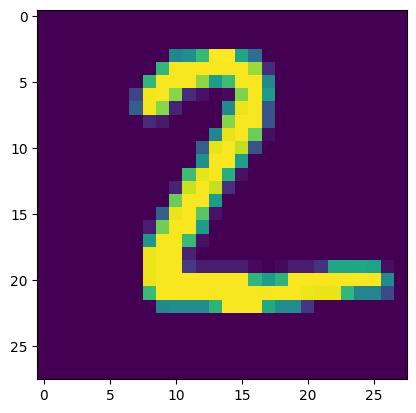

In [11]:
img = X_test[1].reshape(28, 28)
plt.imshow(img.squeeze())


In [12]:
model.predict(X_test[1].unsqueeze(0))

tensor([2])

### Computing the Train Accuracy

In [13]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X)
    predictions = torch.argmax(outputs, dim=1)
    
    total += Y.size(0)
    correct += (predictions == Y).sum().item()

accuracy = 100 * correct / total
print(f"Train Accuracy: {accuracy:}%")

Train Accuracy: 99.955%


### Computing the Test Accuracy

In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_test)
    predictions = torch.argmax(outputs, dim=1)
        
    total += Y_test.size(0)
    correct += (predictions == Y_test).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:}%")

Test Accuracy: 97.13%


### Visualizing the weights of first hidden layer

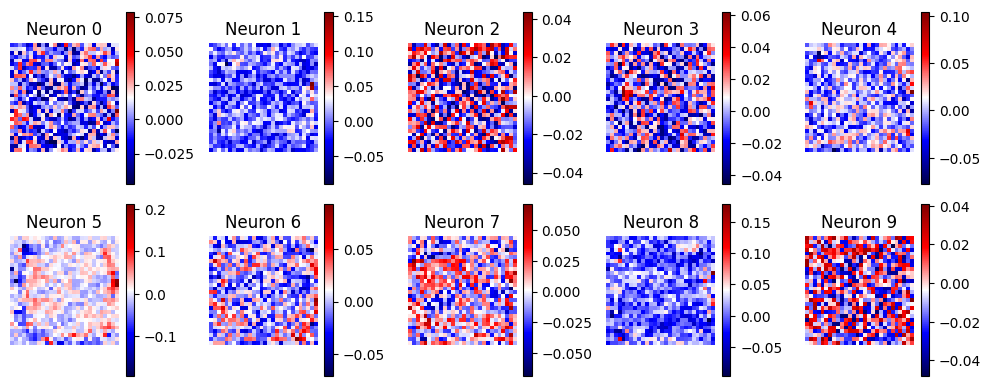

In [15]:
weights = model.input.weight.data.cpu()

plt.figure(figsize=(10, 4))
for i in range(10):
    w = weights[i+10].reshape(28, 28)
    plt.subplot(2, 5, i+1)
    plt.imshow(w, cmap="seismic")
    plt.colorbar()
    plt.title(f"Neuron {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()
